In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
def cntrl(x, x_d, K_p, K_d):
    assert x.shape == (6, 1)
    assert x_d.shape == (6, 1)

    e = x - x_d

    # PD <- PID will need to remember error, bigger state
    u_1 = -1 * (K_p * e[0] + K_d * e[3])
    u_2 = -1 * (K_p * e[1] + K_d * e[4])
    u_3 = -1 * (K_p * e[2] + K_d * e[5])
    u = np.array([[u_1], [u_2], [u_3]])  # control input
    u.resize((3, 1))  # ensure shape is (3, 1)
    assert u.shape == (3, 1)

    return u

    
def dyn(x, I, u):
    assert x.shape == (6, 1)

    I_1, I_2, I_3 = I
    M_1, M_2, M_3 = u

    x_dot = np.zeros((6, 1))  # Initialize the state derivative

    x_dot[0] = x[3]
    x_dot[1] = x[4]
    x_dot[2] = x[5]
    
    x_dot[3] = 1/I_1 * (M_1 - (I_3 - I_2) * x[4] * x[5])
    x_dot[4] = 1/I_2 * (M_2 - (I_1 - I_3) * x[5] * x[3])
    x_dot[5] = 1/I_3 * (M_3 - (I_2 - I_1) * x[3] * x[4])

    return x_dot

In [105]:
delta_t = 0.01  # time step
#       0      1     2    3       4      5
# x = [roll, pitch, yaw, omg_1, omg_2, omg_3]

x = np.zeros((6, 1))  # initial conditions for the state vector

t = 0  # initial time

In [108]:
# Simple Inertia Matrix
I = np.array([100, 110, 120])  # Inertia matrix

# Blue Ring Mockup, assuming a cylindrical body w/o solar panels
m = 2000 #kg, mass of the Blue Ring body
r = 2.5 # m, radius of Blue Ring body
h = 5 # m, height of Blue Ring body

I_cyc = np.array([1/12*m*(3*r**2 + h**2), 1/12*m*(3*r**2 + h**2), 1/2*m*r**2]) # Ixx, Iyy, Izz
print("Inertia Matrix (Cylindrical Body):", I_cyc)

# Blue Ring Mockup, cylindrical body plus payload
m_pay = 500  # kg, mass of the payload
s_pay = 1.0  # m, side length of the payload cube
I_pay = np.array([1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2])

# parallel axis theorm, rotate about the satellite body principle axis
d_x = r + s_pay/2   # distance from the center of the Blue Ring to the center of the payload cube
d_y = 0    # distance from the center of the Blue Ring to the center of the payload cube
d_z = r + s_pay/2   # <-- start to increase this to mount the payload further from the center of the Blue Ring

I_comp = I_cyc + I_pay + np.array([m_pay*d_x**2, m_pay*d_y**2, m_pay*d_z**2]) # x, y, z adjustment to inertia matrix
print("Inertia Matrix (Cylindrical Body + Payload):", I_comp)

d_x_2 = np.sqrt((r + s_pay/2)**2 + 2.5**2)   # distance from the center of the Blue Ring to the center of the payload cube
d_y_2 = 2.5         # distance from the center of the Blue Ring to the center of the payload cube
d_z_2 = r + s_pay/2 # <-- start to increase this to mount the payload further from the center of the Blue Ring

I_comp_2 = I_cyc + I_pay + np.array([m_pay*d_x_2**2, m_pay*d_y_2**2, m_pay*d_z_2**2]) # x, y, z adjustment to inertia matrix
print("Inertia Matrix (Cylindrical Body + Payload+z):", I_comp_2)


Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [11875.          7375.         10833.33333333]
Inertia Matrix (Cylindrical Body + Payload+z): [15000.         10500.         10833.33333333]


In [106]:
while( t < 200):
    
    curr_x = x[:, -1].reshape(-1, 1)  # last column of x
    x_desired = np.array([[0], [0], [np.pi/6], [0], [0], [0]])  # target roll, pitch, yaw, omg_1, omg_2, omg_3

    K_p = 20
    K_d = 400

    # Compute Control Input
    u = cntrl(curr_x, x_desired, K_p, K_d)

    # Compute the state derivative
    x_dot = dyn(curr_x, I_comp, u)
    assert x_dot.shape == (6, 1)

    # Simulate the system using Euler Integration
    next_x = curr_x + x_dot * delta_t

    x = np.hstack((x, next_x))  # append the new state to x

    t += delta_t

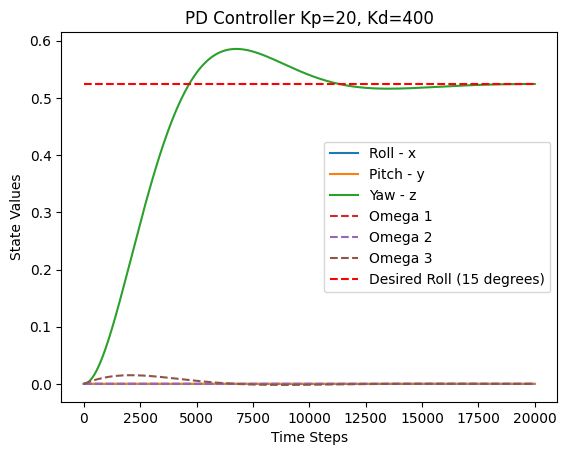

In [107]:
plt.plot(x[0, :], label='Roll - x')
plt.plot(x[1, :], label='Pitch - y')
plt.plot(x[2, :], label='Yaw - z')
plt.plot(x[3, :], label='Omega 1', linestyle='--')
plt.plot(x[4, :], label='Omega 2', linestyle='--')
plt.plot(x[5, :], label='Omega 3', linestyle='--')
plt.title(f'PD Controller Kp={K_p}, Kd={K_d}')
plt.hlines(y=np.pi/6, xmin=0, xmax=x.shape[1]-1, colors='r', linestyles='dashed', label='Desired Roll (15 degrees)')
plt.xlabel('Time Steps')
plt.ylabel('State Values')
plt.legend()
plt.show()

# Additional Resources
1. https://ntrs.nasa.gov/api/citations/20110007876/downloads/20110007876.pdf